In [1]:
from qiskit.converters import dag_to_circuit
from qiskit.dagcircuit import DAGCircuit
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag
from qiskit.dagcircuit import DAGDependency
from qiskit.visualization import circuit_drawer
from qiskit.visualization import dag_drawer



def flatten_dag_to_linear(dag):
    """
    Convert a DAGCircuit into a single-path DAG
    by serializing operations in topological order.
    """

    # Create a new empty DAG
    linear_dag = DAGCircuit()
    linear_dag.add_qreg(dag.qregs["q"])
    
    # Copy classical registers if present
    for creg in dag.cregs.values():
        linear_dag.add_creg(creg)

    # Iterate in topological order
    for node in dag.topological_op_nodes():
        linear_dag.apply_operation_back(
            node.op,
            qargs=node.qargs,
            cargs=node.cargs
        )

    return linear_dag

def load_qasm_to_dag(qasm_path: str):
    qc = QuantumCircuit.from_qasm_file(qasm_path)
    dag = circuit_to_dag(qc)
    return dag

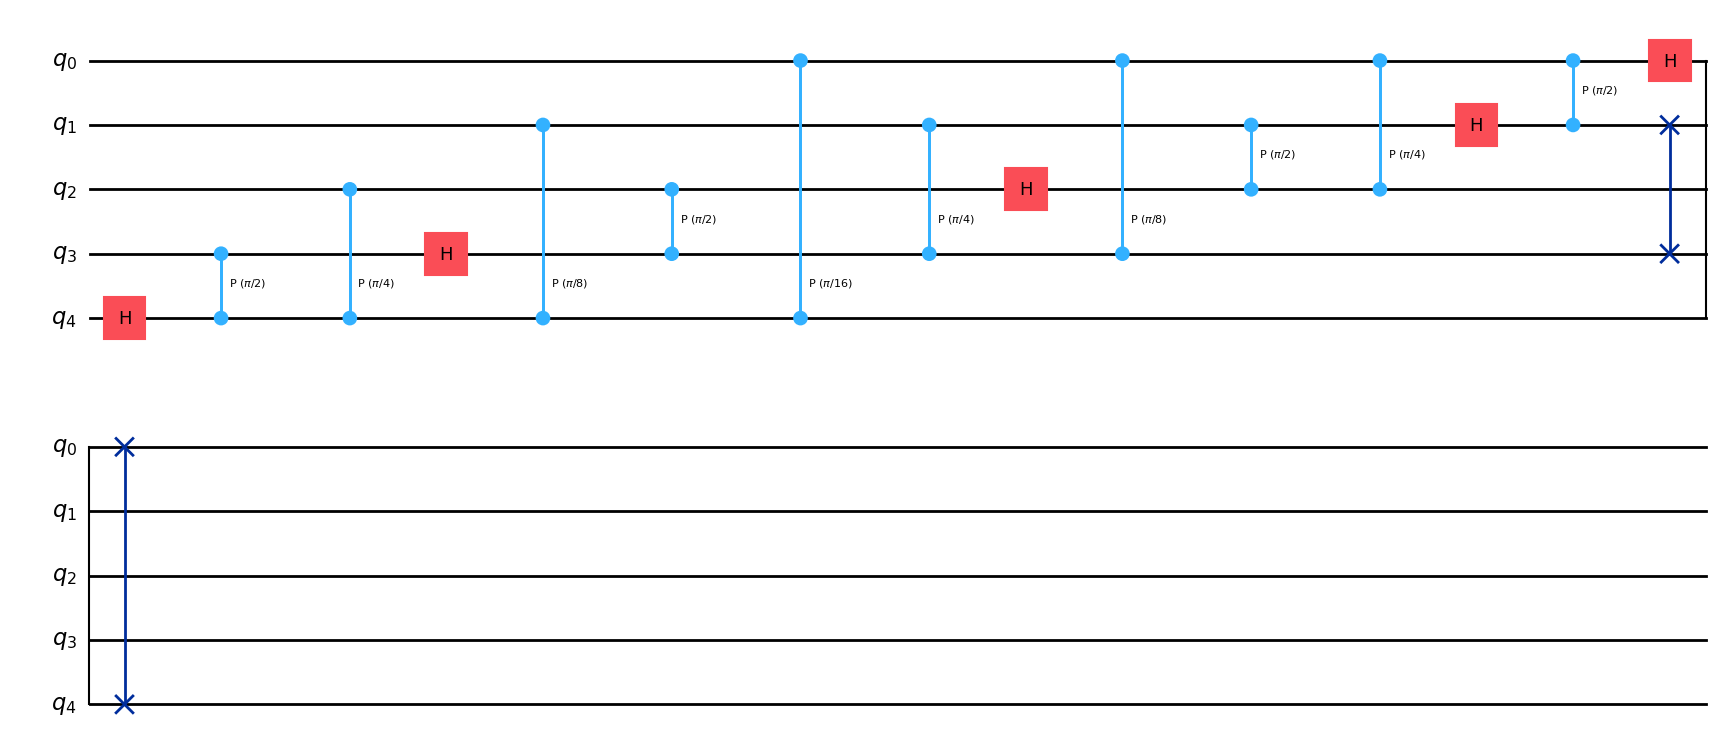

In [2]:
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_5.qasm")
qc.draw("mpl")


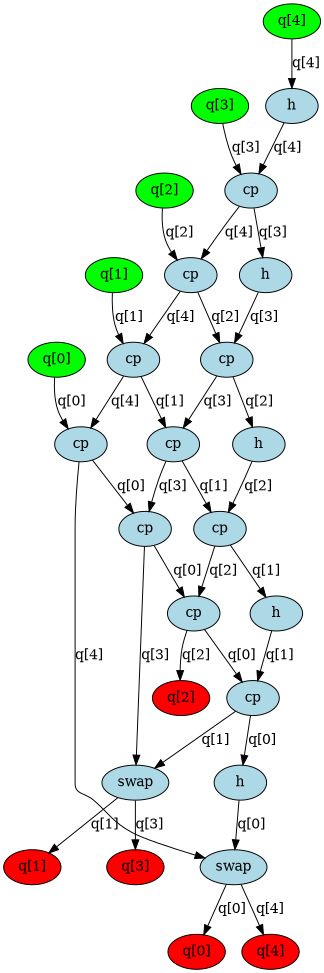

In [3]:
qc = QuantumCircuit.from_qasm_file("inputs/qasm_files/qft_5.qasm")
dag = circuit_to_dag(qc)

dag_drawer(dag)

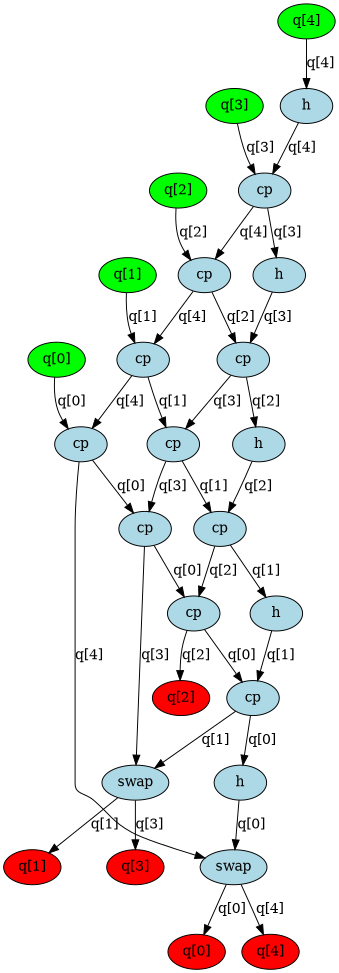

In [4]:
dag = flatten_dag_to_linear(dag)
dag_drawer(dag)

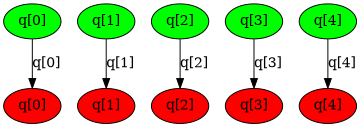

In [5]:
linear_dag = DAGCircuit()
linear_dag.add_qreg(dag.qregs["q"])

dag_drawer(linear_dag)

In [6]:
for d in dag.collect_2q_runs():
    print(d)

[DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=4>,), cargs=()), DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[1.5707963267948966]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=3>), cargs=()), DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=3>,), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.7853981633974483]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=2>), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[1.5707963267948966]), qargs=(<Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=2>), cargs=()), DAGOpNode(op=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qargs=(<Qubit register=(5, "q"), index=2>,), cargs=())]
[DAGOpNode(op=Instruction(name='cp', num_qubits=2

In [7]:
dag.node(16)
#TODO: turn circuit into dag, get rid of unnecessary gate operations, do add barrier before measurments, and preform operations in direction of dag.

DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.39269908169872414]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=1>), cargs=())

In [8]:
from naive_dag.dag_helper import dag_with_gate_ops_only
dag1=dag_with_gate_ops_only(dag)

In [26]:
print("gate_name: ", dag1[1].op.name)
print("params: ", [q for q in dag1[1].op.params])

gate_name:  cp
params:  [1.5707963267948966]


In [38]:
dag1[1].qargs[1]

<Qubit register=(5, "q"), index=3>

In [40]:
for node in dag.topological_op_nodes():
    print(node.op.name, [q.index for q in node.qargs], node.op.params)


AttributeError: 'qiskit.circuit.Qubit' object has no attribute 'index'

In [114]:
node = dag1[1]  # example

gate_name = node.op.name
params = node.op.params
qubits = [q for q in node.qargs]

print(gate_name, params, qubits)


cp [1.5707963267948966] [<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=3>]


In [131]:
def op_node_signature(node: DAGOpNode) -> tuple[str, list[float], list[int]]:
    """
    Return (gate_name, params, qubit_indices) for a DAGOpNode.

    Qubit indices are extracted from node.qargs (e.g., q[3] -> 3).
    """
    gate_name = node.op.name
    params = [float(p) for p in getattr(node.op, "params", [])]
    qubit_indices: list[int] = []
    for q in node.qargs:
        rep = repr(q)
        if "index=" not in rep:
            raise ValueError(f"Unable to extract qubit index from {rep}")
        idx_str = rep.split("index=", 1)[1].split(">", 1)[0].strip()
        idx = int(idx_str)
        qubit_indices.append(int(idx))
    return gate_name, params, qubit_indices


In [138]:
dag1[6]

DAGOpNode(op=Instruction(name='cp', num_qubits=2, num_clbits=0, params=[0.39269908169872414]), qargs=(<Qubit register=(5, "q"), index=4>, <Qubit register=(5, "q"), index=1>), cargs=())

In [1]:
%load_ext autoreload
%autoreload 2
from naive_dag.grid import generate_grid
from naive_dag.grid import naive_fill
from naive_dag.grid import move_qubit
from naive_dag.dag_helper import load_qasm_to_gate_dag
from naive_dag.dynamics import gate_qubits
from naive_dag.dynamics import _start_
from naive_dag.dynamics import _shuttle_
from naive_dag.dynamics import best_path_for_gate


In [2]:
qc = load_qasm_to_gate_dag("inputs/qasm_files/qft_6.qasm")
grid = generate_grid([3,3],1)
qubits = naive_fill(grid,6,0,True)

In [5]:
qc[0].op

Instruction(name='h', num_qubits=1, num_clbits=0, params=[])

In [100]:
len(qc)

21

In [82]:
q1, q2 = gate_qubits(qc, 1, qubits)
print(q1.grid_position())
print(q2.grid_position())

(2, 2)
(0, 4)


In [83]:
moves=best_path_for_gate(qc,1,qubits,grid)
moves

[(2, 2), (1, 2), (1, 4)]

In [84]:
q1, q2 = gate_qubits(qc, 3, qubits)
print(q1.grid_position())
print(q2.grid_position())

(1, 4)
(0, 0)


In [85]:
moves=best_path_for_gate(qc,3,qubits,grid)
moves

[(1, 4), (1, 0), (1, 2), (0, 2)]

In [ ]:
gate_qubits(qc, 3, qubits)

In [90]:
from naive_dag.main import resolve_config_paths
from naive_dag.main import load_config
import pint
ureg = pint.UnitRegistry()
config = load_config("inputs/algorithms/qft_06.json")

In [96]:
import json
import pint

ureg = pint.UnitRegistry()

with open("inputs/algorithms/qft_06.json") as f:
    config = json.load(f)

def to_quantity(d):
    return d["value"] * ureg(d["units"])

config["transfer_SLM_AOD"] = to_quantity(config["transfer_SLM_AOD"])
config["max_acceleration"] = to_quantity(config["max_acceleration"])
config["max_velocity"] = to_quantity(config["max_velocity"])
config["rydberg_radius"] = to_quantity(config["rydberg_radius"])

In [97]:
config["transfer_SLM_AOD"] = config["transfer_SLM_AOD"].to("seconds")

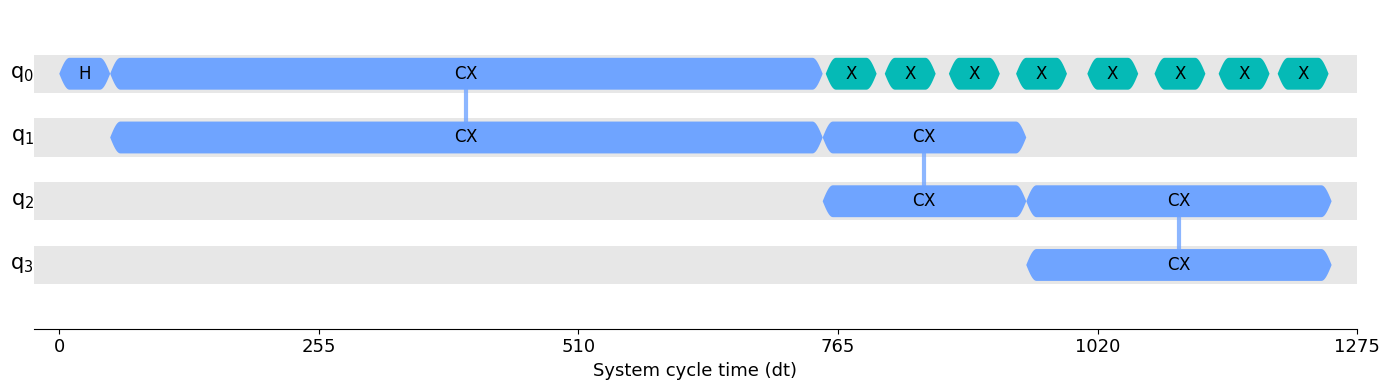

In [115]:
import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager, InstructionDurations, Target, CouplingMap
from qiskit.transpiler.passes import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit.visualization import timeline_drawer

circ = QuantumCircuit(4)
circ.h(0)
circ.cx(0, 1)
circ.cx(1, 2)
circ.cx(2, 3)
durations = InstructionDurations(
    [("h", 0, 50), ("cx", [0, 1], 700), ("reset", None, 10),
     ("cx", [1, 2], 200), ("cx", [2, 3], 300),
     ("x", None, 50), ("measure", None, 1000)],
    dt=1e-7
)
target = Target.from_configuration(
    ["h", "cx", "reset", "x", "measure"],
    num_qubits=4,
    coupling_map=CouplingMap.from_line(4, bidirectional=False),
    instruction_durations=durations,
    dt=1e-7,
)

# balanced X-X sequence on all qubits
dd_sequence = [XGate(), XGate()]
pm = PassManager([ALAPScheduleAnalysis(durations),
                  PadDynamicalDecoupling(durations, dd_sequence)])
circ_dd = pm.run(circ)
timeline_drawer(circ_dd, target=target)

# Uhrig sequence on qubit 0
n = 8
dd_sequence = [XGate()] * n
def uhrig_pulse_location(k):
    return np.sin(np.pi * (k + 1) / (2 * n + 2)) ** 2
spacing = []
for k in range(n):
    spacing.append(uhrig_pulse_location(k) - sum(spacing))
spacing.append(1 - sum(spacing))
pm = PassManager(
    [
        ALAPScheduleAnalysis(durations),
        PadDynamicalDecoupling(durations, dd_sequence, qubits=[0], spacing=spacing),
    ]
)
circ_dd = pm.run(circ)
timeline_drawer(circ_dd, target=target)

In [116]:
durations